In [1]:
# raw data

# understand the problem

# features X / target Y

# split train / test

# EDA using 

# preprocess based on training

#   appply preprocess to text

# data ready for a model


# train -> evaluate -> predict


In [4]:
import pandas as pd
import numpy as np
df_raw=pd.read_csv("airfoil_self_noise.dat",sep=r"\s+",header=None)


In [6]:
df_raw.shape
df_raw.columns=["Freq","angle","chord","vel","thick","noise"]

In [7]:
# audit data
df_raw.dtypes

Freq       int64
angle    float64
chord    float64
vel      float64
thick    float64
noise    float64
dtype: object

In [8]:
df_raw.nunique()

Freq       21
angle      27
chord       6
vel         4
thick     105
noise    1456
dtype: int64

In [9]:
df_raw.isna().sum()

Freq     0
angle    0
chord    0
vel      0
thick    0
noise    0
dtype: int64

In [10]:
df_raw.nunique()

Freq       21
angle      27
chord       6
vel         4
thick     105
noise    1456
dtype: int64

In [19]:
# prediction task: predict noise from variables: freq, angle, chord, vel, thick
target="noise"
X=df_raw.drop(columns=target).copy()
Y=df_raw[target].copy()

In [21]:
X

,Freq,angle,chord,vel,thick
0,800,0.0,0.3048,71.3,0.002663
1,1000,0.0,0.3048,71.3,0.002663
2,1250,0.0,0.3048,71.3,0.002663
3,1600,0.0,0.3048,71.3,0.002663
4,2000,0.0,0.3048,71.3,0.002663
...,...,...,...,...,...
1498,2500,15.6,0.1016,39.6,0.052849
1499,3150,15.6,0.1016,39.6,0.052849
1500,4000,15.6,0.1016,39.6,0.052849
1501,5000,15.6,0.1016,39.6,0.052849


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, random_state=42)

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [25]:
X_test.head()
Y_test.head()

51      125.045
1465    118.767
184     120.233
1000    137.047
746     134.556
Name: noise, dtype: float64

In [ ]:
preprocessing=Pipeline([("scaling",StandardScaler())])
#model=Pipeline([("scaling", StandardScaler())])

In [29]:
X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

In [31]:
X_train.min()

Freq     200.000000
angle      0.000000
chord      0.025400
vel       31.700000
thick      0.000401
dtype: float64

In [33]:
X_train_prepared

array([[-0.5864537 ,  0.28003006, -0.92882303,  1.28327983, -0.44429244],
       [-0.27318356, -0.01135064, -0.3850114 ,  1.28327983, -0.48364048],
       [-0.77441579,  0.94849167, -0.3850114 ,  0.26898246,  1.97746879],
       ...,
       [-0.70236365,  0.75995122, -0.92882303, -0.75173452,  0.30483513],
       [-0.80104375,  0.94849167, -0.3850114 , -1.2588832 ,  2.3655493 ],
       [ 0.66662688,  1.01705184, -1.20072884,  1.28327983,  0.08461329]],
      shape=(1202, 5))

In [34]:
pd.DataFrame(X_train_prepared, columns=X_train.columns).min()

Freq    -0.837070
angle   -1.159733
chord   -1.200729
vel     -1.258883
thick   -0.820249
dtype: float64

In [35]:
from sklearn.linear_model import LinearRegression

In [37]:
model = LinearRegression()
model.fit(X_train_prepared,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-4.06,-2.37,-3.22, 1.53,-1.82]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,124.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[50.55,36.66,33.03,28.53,14.34]"


In [38]:
model.coef_

array([-4.05944704, -2.36673679, -3.21995215,  1.526901  , -1.81559015])

In [39]:
model.intercept_

np.float64(124.87696006655574)

In [40]:
Y_pred=model.predict(X_test_prepared)

In [49]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'NOISE')

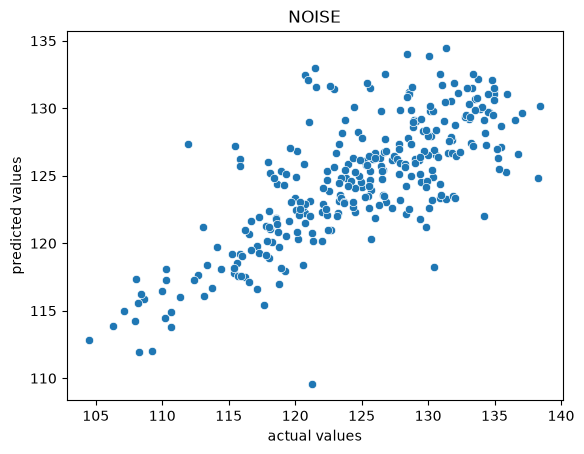

In [52]:
sns.scatterplot(x=Y_test, y=Y_pred)
plt.xlabel("actual values")
plt.ylabel("predicted values")
plt.title("NOISE")

In [53]:
from sklearn.metrics import mean_squared_error

In [55]:
np.sqrt(mean_squared_error(Y_pred, Y_test))

np.float64(4.704109194974887)

In [56]:
from sklearn.metrics import root_mean_squared_error

In [57]:
root_mean_squared_error(Y_pred, Y_test)

4.704109194974887